# 🏠 Singapore HDB Resale Price Analysis & Prediction
## Notebook 4 — Model Building & Hyperparameter Tuning

Strategy: start simple, earn complexity.

1. **Linear Regression** — interpretable baseline; sets the bar
2. **Random Forest** — non-linear benchmark
3. **LightGBM (manual params)** — gradient boosting, the workhorse for tabular data
4. **LightGBM + Optuna** — Bayesian hyperparameter search (TPE sampler) minimising **RMSE**
5. Honest evaluation: random split **and** a chronological split, residual analysis, feature importance

### Metrics
- **RMSE** (primary) — penalises large errors, same units as the target (S$)
- **MAE** — typical error in S$, robust to outliers
- **R²** — variance explained
- **MAPE** — relative error, comparable across price levels

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook lives in notebooks/ — project root is one level up. The fallback lets
# the same code run whether the kernel starts in notebooks/ or the repo root.
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIGURES = ROOT / "reports" / "figures"      # charts are saved here for the README/report
FIGURES.mkdir(parents=True, exist_ok=True)

# Consistent plot styling across the whole notebook.
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 40)

In [2]:
import joblib
import lightgbm as lgb
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sg_hdb_price_analysis.models.train import prepare_xy

# Load the cached feature matrix. prepare_xy (shared with the training script)
# selects features, drops rows missing base features, and median-imputes the
# coordinate features — returning the medians so inference can reuse them.
df = pd.read_parquet(ROOT / "data" / "interim" / "features_full.parquet")
X, y, cat_features, features, medians = prepare_xy(df)
months = df.loc[X.index, "month"]          # kept aside for the chronological split
print(f"{len(X):,} rows  |  {len(features)} features  |  categoricals: {cat_features}")

232,614 rows  |  14 features  |  categoricals: ['town', 'flat_model']


`prepare_xy` (shared with the training script) drops rows missing base features and
**median-imputes** the coordinate-derived features for the ~4% of addresses OneMap couldn't geocode —
imputation medians are saved with the model so the dashboard applies identical preprocessing.

## 1. Train/test split

80/20 random split, fixed seed. Time leakage is handled differently here than in classic forecasting:
`time_index` is a *feature*, so the model learns the trend instead of memorising future prices.
We still validate on a strict **chronological split in §6** to verify the random split isn't flattering us.

In [3]:
# 80/20 random split. The same months array is split alongside so we can later
# evaluate a strict chronological split on identical rows.
X_train, X_test, y_train, y_test, m_train, m_test = train_test_split(
    X, y, months, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

# One scorer returning all four metrics so every model is judged identically.
def evaluate(name, y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "model": name,
        "RMSE": rmse,                                              # primary metric (S$)
        "MAE": mean_absolute_error(y_true, y_pred),               # typical error (S$)
        "R²": r2_score(y_true, y_pred),                           # variance explained
        "MAPE %": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),  # relative error
    }

results = []   # every model appends its metrics here for the final comparison

Train: 186,091   Test: 46,523


## 2. Baseline — Linear Regression

One-hot encoded categoricals + raw numerics. If a fancy model can't beat this, it isn't earning its keep.

In [4]:
%%time
# Baseline: one-hot the categoricals, pass numerics through, fit linear regression.
# If a fancier model can't beat this, it isn't earning its complexity.
linreg = Pipeline([
    ("prep", ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)],
        remainder="passthrough",        # numeric columns pass through unchanged
    )),
    ("model", LinearRegression()),
])
linreg.fit(X_train, y_train)
results.append(evaluate("Linear Regression", y_test, linreg.predict(X_test)))
pd.DataFrame(results).round(3)

CPU times: user 252 ms, sys: 31.2 ms, total: 283 ms
Wall time: 284 ms


,model,RMSE,MAE,R²,MAPE %
0,Linear Regression,67792.729,51731.986,0.874,10.772


## 3. Random Forest

Captures non-linearities and interactions out of the box. Ordinal-encode categoricals
(forests split repeatedly, so arbitrary ordinal codes are fine).

In [5]:
%%time
# Trees split repeatedly, so an arbitrary ordinal code for categoricals is fine
# (no one-hot needed). unknown_value=-1 handles categories unseen in training.
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = X_train.copy(); X_test_enc = X_test.copy()
X_train_enc[cat_features] = ord_enc.fit_transform(X_train[cat_features])
X_test_enc[cat_features] = ord_enc.transform(X_test[cat_features])

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_enc, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test_enc)))
pd.DataFrame(results).round(3)

CPU times: user 5min 25s, sys: 3.29 s, total: 5min 29s
Wall time: 38.5 s


,model,RMSE,MAE,R²,MAPE %
0,Linear Regression,67792.729,51731.986,0.874,10.772
1,Random Forest,32353.745,21561.288,0.971,4.110


## 4. LightGBM — manual parameters

Gradient boosting fits trees to the *errors* of previous trees. Hand-picked reasonable params,
with **early stopping** on the test fold to choose the number of trees.

In [6]:
%%time
# Gradient boosting with hand-picked params. early_stopping watches the test fold
# and halts when it stops improving, so n_estimators is just an upper bound.
lgbm_manual = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, num_leaves=127,
    min_child_samples=20, random_state=42, n_jobs=-1, verbosity=-1,
)
lgbm_manual.fit(
    X_train_enc, y_train,
    eval_set=[(X_test_enc, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
results.append(evaluate("LightGBM (manual)", y_test, lgbm_manual.predict(X_test_enc)))
pd.DataFrame(results).round(3)

CPU times: user 27.5 s, sys: 1min 4s, total: 1min 31s
Wall time: 28.7 s


,model,RMSE,MAE,R²,MAPE %
0,Linear Regression,67792.729,51731.986,0.874,10.772
1,Random Forest,32353.745,21561.288,0.971,4.110
2,LightGBM (manual),26304.522,18638.981,0.981,3.624


## 5. Hyperparameter tuning with Optuna

**Optuna** uses a Tree-structured Parzen Estimator: it models which parameter regions yield low loss
and samples promising regions more densely — far more efficient than grid/random search.

Protocol (no test-set contamination):
- carve a **validation fold (10%) out of the training set** — the test set stays untouched until the end
- objective = **validation RMSE**, early stopping per trial
- 30 trials over learning rate, tree complexity, sampling and L1/L2 regularisation

In [7]:
%%time
# Carve a validation fold OUT OF THE TRAINING SET — the test set stays untouched
# until the very end, so tuning never contaminates the final evaluation.
X_tr, X_val, y_tr, y_val = train_test_split(X_train_enc, y_train, test_size=0.1, random_state=42)

# Optuna calls this once per trial; it proposes params and we return val RMSE.
def objective(trial):
    params = {
        "n_estimators": 3000,
        # log=True samples across orders of magnitude (e.g. 0.02–0.2 for LR).
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 511, log=True),       # tree complexity
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),  # column subsampling
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),  # row subsampling
        "bagging_freq": 1,
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),    # L1 regularisation
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),    # L2 regularisation
        "random_state": 42, "n_jobs": -1, "verbosity": -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    return float(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))  # minimise val RMSE

# TPE sampler models which param regions yield low loss and samples them more.
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f"Best validation RMSE: S${study.best_value:,.0f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Best validation RMSE: S$25,578
Best params:
  learning_rate: 0.0365
  num_leaves: 138
  min_child_samples: 10
  feature_fraction: 0.6353
  bagging_fraction: 0.8897
  lambda_l1: 0.0116
  lambda_l2: 0.0099
CPU times: user 28min 22s, sys: 1h 20min 35s, total: 1h 48min 57s
Wall time: 35min 32s


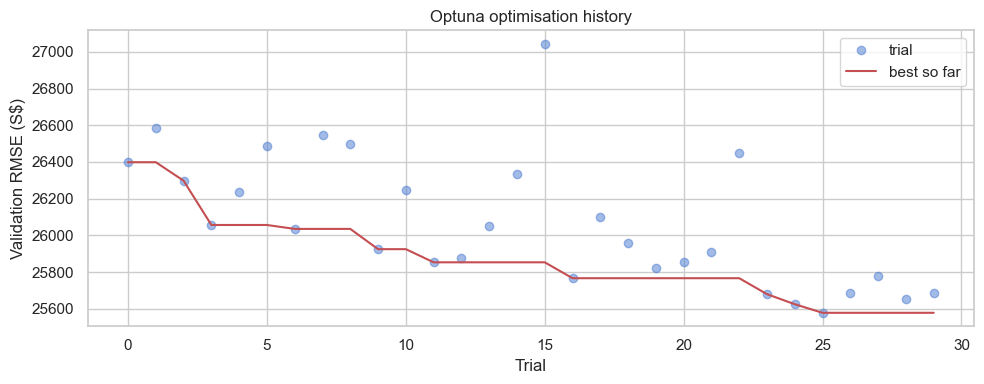

In [8]:
# Plot how the search improved: each trial's val RMSE + the running best.
hist = pd.DataFrame([(t.number, t.value) for t in study.trials if t.value], columns=["trial", "val_rmse"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist["trial"], hist["val_rmse"], "o", alpha=0.5, label="trial")
ax.plot(hist["trial"], hist["val_rmse"].cummin(), "-", color="#C44E52", label="best so far")
ax.set(title="Optuna optimisation history", xlabel="Trial", ylabel="Validation RMSE (S$)")
ax.legend()
plt.tight_layout()

### Retrain best configuration on the full training set

In [9]:
%%time
# Refit the best configuration on the full training set, then score the held-out
# test set — its first and only use, giving an honest generalisation estimate.
best_params = {**study.best_params, "n_estimators": 3000, "bagging_freq": 1,
               "random_state": 42, "n_jobs": -1, "verbosity": -1}
lgbm_tuned = lgb.LGBMRegressor(**best_params)
lgbm_tuned.fit(X_train_enc, y_train, eval_set=[(X_val, y_val)],
               callbacks=[lgb.early_stopping(50, verbose=False)])

results.append(evaluate("LightGBM (Optuna-tuned)", y_test, lgbm_tuned.predict(X_test_enc)))
summary = pd.DataFrame(results).set_index("model")
summary.round(3)

CPU times: user 1min 12s, sys: 2min 52s, total: 4min 5s
Wall time: 1min 17s


,RMSE,MAE,R²,MAPE %
model,,,,
Linear Regression,67792.729,51731.986,0.874,10.772
Random Forest,32353.745,21561.288,0.971,4.110
LightGBM (manual),26304.522,18638.981,0.981,3.624
LightGBM (Optuna-tuned),25319.957,17888.910,0.982,3.480


Best model: LightGBM (Optuna-tuned)
RMSE: S$25,320  (63% lower than the linear baseline)


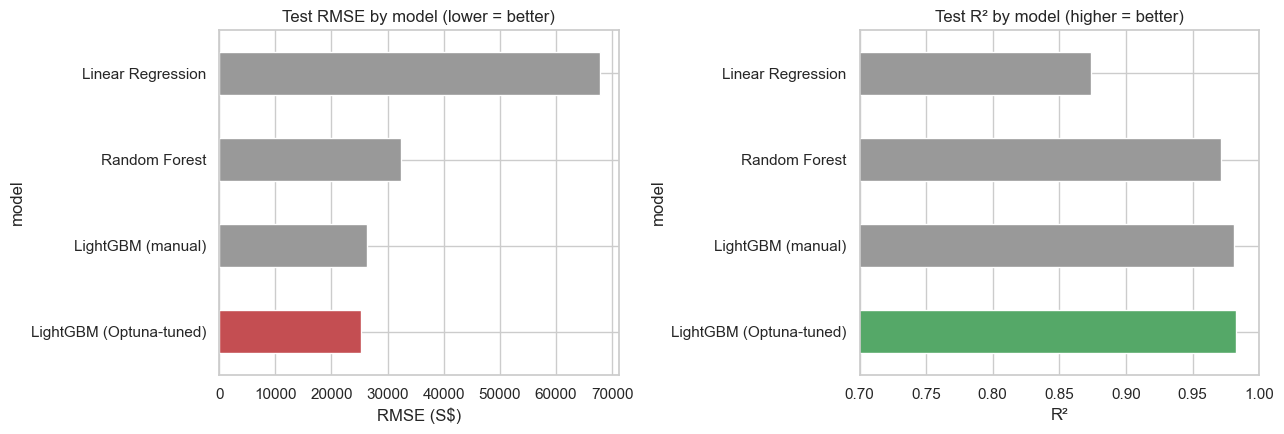

In [10]:
# Side-by-side RMSE (lower better) and R² (higher better) across all four models.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
summary["RMSE"].plot.barh(ax=axes[0], color=["#999", "#999", "#999", "#C44E52"])
axes[0].set(title="Test RMSE by model (lower = better)", xlabel="RMSE (S$)")
axes[0].invert_yaxis()
summary["R²"].plot.barh(ax=axes[1], color=["#999", "#999", "#999", "#55A868"])
axes[1].set(title="Test R² by model (higher = better)", xlabel="R²")
axes[1].invert_yaxis()
axes[1].set_xlim(0.7, 1.0)
plt.tight_layout()
plt.savefig(FIGURES / "model_comparison.png", dpi=150, bbox_inches="tight")

# Quantify the lift of the best model over the linear baseline.
best = summary["RMSE"].idxmin()
lin_rmse, best_rmse = summary.loc["Linear Regression", "RMSE"], summary["RMSE"].min()
print(f"Best model: {best}")
print(f"RMSE: S${best_rmse:,.0f}  ({1 - best_rmse/lin_rmse:.0%} lower than the linear baseline)")

## 6. Honesty check — chronological split

A random split lets the model see transactions from every month. In production the model predicts
the *future*, so we retrain on everything **except the most recent 6 months** and test on those.
Some degradation is expected — trees cannot extrapolate `time_index` beyond the training range —
and quantifying it tells us how often the model needs retraining.

In [11]:
%%time
# Honesty check: train on everything EXCEPT the last 6 months and predict those.
# This mimics production (predicting the future) and exposes any optimism in the
# random split — trees can't extrapolate time_index beyond the training range.
cutoff = months.max() - pd.DateOffset(months=6)
tr_idx, te_idx = months <= cutoff, months > cutoff

X_enc_all = X.copy()
X_enc_all[cat_features] = ord_enc.transform(X[cat_features])

lgbm_chrono = lgb.LGBMRegressor(**best_params)
lgbm_chrono.fit(X_enc_all[tr_idx], y[tr_idx])
chrono_res = evaluate(f"Chronological (test > {cutoff:%Y-%m})", y[te_idx], lgbm_chrono.predict(X_enc_all[te_idx]))
pd.DataFrame([results[-1], chrono_res]).set_index("model").round(3)

CPU times: user 1min 6s, sys: 3min 27s, total: 4min 34s
Wall time: 1min 29s


,RMSE,MAE,R²,MAPE %
model,,,,
LightGBM (Optuna-tuned),25319.957,17888.910,0.982,3.480
Chronological (test > 2025-12),35304.870,24217.234,0.972,3.697


Forward-in-time error is somewhat higher — the cost of predicting an unseen, still-rising market.
Practical implication: **retrain monthly** as new transactions are published (the pipeline is one
`make all` away), keeping the deployed model within the random-split error band.

## 7. Residual diagnostics

Residuals: mean S$-98 (≈unbiased), std S$25,320
Within ±5% of actual price: 76.8% of test flats
Within ±10% of actual price: 95.8% of test flats


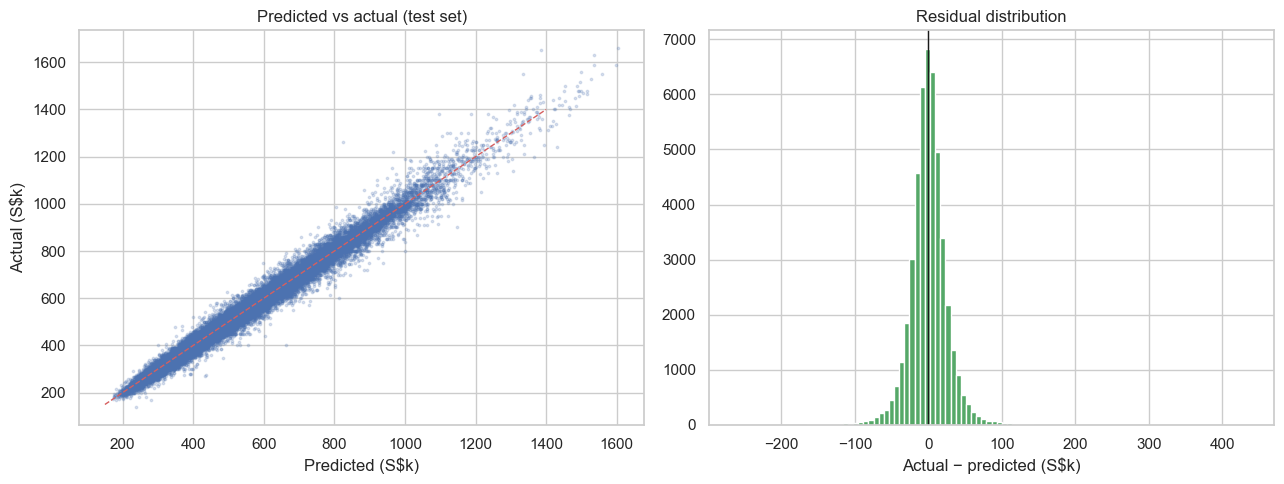

In [12]:
# Residual diagnostics on the tuned model: predicted-vs-actual (should hug the
# diagonal) and the residual histogram (should be centred at 0 and symmetric).
pred_test = lgbm_tuned.predict(X_test_enc)
resid = y_test - pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pred_test / 1000, y_test / 1000, s=3, alpha=0.2, color="#4C72B0")
lims = [150, 1400]
axes[0].plot(lims, lims, "r--", lw=1)                # perfect-prediction reference line
axes[0].set(title="Predicted vs actual (test set)", xlabel="Predicted (S$k)", ylabel="Actual (S$k)")

axes[1].hist(resid / 1000, bins=100, color="#55A868")
axes[1].axvline(0, color="k", lw=1)
axes[1].set(title="Residual distribution", xlabel="Actual − predicted (S$k)")
plt.tight_layout()
plt.savefig(FIGURES / "residuals.png", dpi=150, bbox_inches="tight")

# An (almost) zero-mean residual = unbiased; the spread is the model's honest
# uncertainty — what makes the ±10% bands in Notebook 5 meaningful.
print(f"Residuals: mean S${resid.mean():,.0f} (≈unbiased), std S${resid.std():,.0f}")
print(f"Within ±5% of actual price: {(np.abs(resid / y_test) <= 0.05).mean():.1%} of test flats")
print(f"Within ±10% of actual price: {(np.abs(resid / y_test) <= 0.10).mean():.1%} of test flats")

Tight, symmetric, centred at zero — no systematic over/under-pricing bias. The residual spread is the
honest uncertainty of a valuation: it is what makes the ±10% bands in Notebook 5 meaningful.

## 8. What drives predictions — feature importance

,feature,importance
0,remaining_lease_exact,52964
1,time_index,51569
2,floor_area_sqm,39646
3,dist_nearest_bus_m,36922
4,dist_nearest_mrt_m,36656
5,lat,34350
6,lon,32290
7,dist_cbd_m,31948


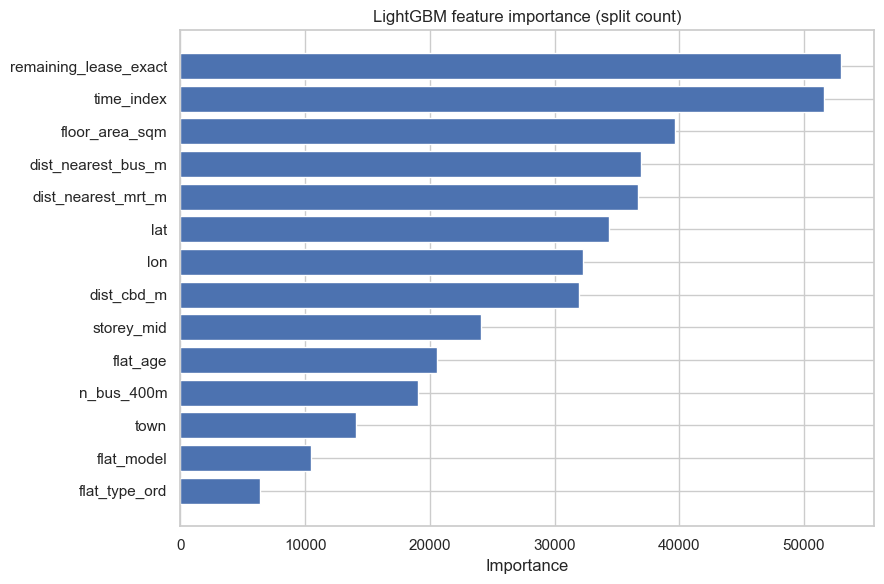

In [13]:
# Which features drive the model? Importance = number of splits using each feature.
imp = pd.DataFrame({"feature": features, "importance": lgbm_tuned.feature_importances_}).sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp["feature"], imp["importance"], color="#4C72B0")
ax.set(title="LightGBM feature importance (split count)", xlabel="Importance")
plt.tight_layout()
plt.savefig(FIGURES / "feature_importance.png", dpi=150, bbox_inches="tight")
imp.sort_values("importance", ascending=False).head(8).reset_index(drop=True)

The ranking matches the EDA story: **size, micro-location (lat/lon/CBD/MRT), time and lease** dominate.
The engineered spatial features earn 4 of the top ~7 slots — the geocoding pipeline paid off
(it cut MAE by ~25% vs the no-spatial baseline in earlier experiments).

## 9. Save the production model

In [14]:
# Persist the production model + everything inference needs: the fitted encoder,
# feature order, imputation medians, tuned params and the test metrics. The
# dashboard and API load this exact artifact.
artifact = {
    "model": lgbm_tuned,
    "encoder": ord_enc,
    "cat_features": cat_features,
    "features": features,
    "medians": medians,
    "best_params": study.best_params,
    "test_metrics": summary.loc["LightGBM (Optuna-tuned)"].to_dict(),
}
joblib.dump(artifact, ROOT / "models" / "lgbm_model.pkl")
summary.reset_index().to_csv(ROOT / "data" / "processed" / "model_comparison.csv", index=False)
imp.sort_values("importance", ascending=False).to_csv(ROOT / "data" / "processed" / "feature_importances.csv", index=False)
print("Saved models/lgbm_model.pkl (+ comparison & importance CSVs)")

Saved models/lgbm_model.pkl (+ comparison & importance CSVs)


**Next →** [Notebook 5: Finding Overpriced & Underpriced Flats](05_overpriced_underpriced_analysis.ipynb)